# Phase 3 — Crop-Season-Aware Yield Mapping

Maps **final harvest-year yield** (`Annual_Yield`) per field from Phase 1 fortnight features.

**Input:** `usa_fortnight_features.csv` (Phase 1)  
**Outputs:**
- `usa_field_annual_yield.csv` — one row per `(field_id, year)`
- `usa_fortnight_yield_mapped.csv` — in-season fortnights + `Annual_Yield` + early estimates (Phase 4 input)

US sugarcane monitoring window: **Mar–Sep** (TX/LA), **Mar–Oct 15** (FL). Jan–Feb and harvest-period fortnights are excluded from mapping and LSTM inputs.


In [13]:
# --- CONFIG ---
INPUT_CSV = 'usa_fortnight_features.csv'
OUTPUT_FIELD_CSV = 'usa_field_annual_yield.csv'
OUTPUT_FORTNIGHT_CSV = 'usa_fortnight_yield_mapped.csv'

CSV_SEARCH_PATHS = [
    'usa_fortnight_features.csv',
    'data/usa_fortnight_features.csv',
    '../data/usa_fortnight_features.csv',
    '/content/usa_fortnight_features.csv',
    '/content/drive/MyDrive/usa_fortnight_features.csv',
]

# USDA NASS state sugarcane yield (tons/acre) — harvest/crop year
STATE_ANNUAL_YIELDS = {
    'Florida':   {2019: 43.0, 2021: 42.6, 2022: 44.6},
    'Louisiana': {2019: 28.1, 2021: 29.3, 2022: 32.3},
    'Texas':     {2019: 33.8, 2021: 30.9, 2022: 22.6},
}

# In-season monitoring windows (crop year = `year` column)
CROP_SEASON = {
    'Louisiana': {
        'monitor_start': '03-01',
        'monitor_end':   '09-30',
        'harvest_start': '10-01',
    },
    'Texas': {
        'monitor_start': '03-01',
        'monitor_end':   '09-30',
        'harvest_start': '10-01',
    },
    'Florida': {
        'monitor_start': '03-01',
        'monitor_end':   '10-15',
        'harvest_start': '10-16',
    },
}

# Weights ported from Yield_Mapping.ipynb (MODIS NDVI/EVI → LAI)
MAPPING_WEIGHTS = {
    'NDVI': 7, 'EVI': 0.4, 'GNDVI': 5, 'SAVI': 1.5,
    'TVI': 0.5, 'CI': 0.01, 'CI1': 0.2, 'SATVI': 1.5,
    'BSI': 0.001, 'MSAVI': 1.5, 'Elevation': 0.01,
    'NBR_8': 1, 'NDMI_8': 1, 'NDWI_8': 1.75,
    'NDBI_8': 1.75, 'NDBaI_8': 1.75, 'MNDWI_8': 1.75,
    'LAI': 8, 'MOISTURE': 0.001,
}

# Scalar-difference calibration
# Features are standardized per state-year (z-scores) so LAI/Elevation don't
# dominate the vegetation indices, then scaled to a fractional yield deviation.
SCALAR_SENSITIVITY = 0.3       # 1 std from state mean -> ~30% yield change
SCALAR_CLIP = (-0.8, 2.0)      # keep Annual_Yield positive and bounded

TEXAS_REFERENCE_PATHS = [
    '../Research Notebooks and Data/Data/Texas Field Yield Data.csv',
    'Research Notebooks and Data/Data/Texas Field Yield Data.csv',
]

In [14]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def resolve_input_csv():
    if os.path.exists(INPUT_CSV):
        return INPUT_CSV
    for path in CSV_SEARCH_PATHS:
        if os.path.exists(path):
            return path
    if IN_COLAB:
        drive_matches = sorted(glob.glob('/content/drive/MyDrive/**/usa_fortnight_features.csv', recursive=True))
        if drive_matches:
            return drive_matches[0]
    if IN_COLAB:
        print(f'{INPUT_CSV} not found — upload Phase 1 output:')
        uploaded = files.upload()
        return next(iter(uploaded))
    raise FileNotFoundError(f'Place {INPUT_CSV} in working directory or data/')


def _md_to_ts(year, md):
    month, day = map(int, md.split('-'))
    return pd.Timestamp(year=int(year), month=month, day=day)


def clean_phase1_export(raw_df):
    df = raw_df.copy()
    drop_cols = ['.geo', 'system:index']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    if 'Area' not in df.columns and 'area' in df.columns:
        df['Area'] = df['area']
    df['fortnight_start'] = pd.to_datetime(df['fortnight_start'])
    if 'fortnight_end' in df.columns:
        df['fortnight_end'] = pd.to_datetime(df['fortnight_end'])
    df['field_id'] = pd.to_numeric(df['field_id'], errors='coerce')
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    before = len(df)
    df = df.drop_duplicates(subset=['field_id', 'fortnight_start'], keep='last')
    if before != len(df):
        print(f'Removed {before - len(df)} duplicate field/fortnight rows')
    return df


csv_path = resolve_input_csv()
print('Loading:', csv_path)
raw_df = pd.read_csv(csv_path)
df = clean_phase1_export(raw_df)
print('Shape:', df.shape)
df.head()

Loading: ../data/usa_fortnight_features.csv
Shape: (50832, 69)


,ASI,Area,B1,B11,B12,B2,B3,B4,B5,B6,...,area,field_id,fortnight_end,fortnight_start,label,mean,s2_scene_count,state,year,state_annual_yield
0,0.274030,26.514191,452.560882,2334.970376,2113.836332,643.106629,815.964104,957.046262,1168.296240,1452.805501,...,26.514191,1.0,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
1,0.200750,0.445614,390.785714,2649.330357,2465.326786,581.816071,702.201786,956.333929,1118.978571,1191.910714,...,0.445614,2.0,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
2,0.203519,0.668428,614.389208,3169.438576,3034.840413,859.788749,1075.184845,1343.337543,1565.591274,1738.748565,...,0.668428,3.0,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
3,0.200886,0.668428,658.382527,3236.122786,3105.825266,884.552538,1098.811098,1364.779221,1587.906730,1754.465171,...,0.668428,4.0,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8
4,0.171391,3.564942,346.524071,2221.554188,2150.813805,551.124643,663.971202,891.705210,1022.420092,1064.955595,...,3.564942,5.0,2019-01-15,2019-01-01,2,45.0,1.0,Texas,2019,33.8


## Crop season filter

Tag in-season fortnights and assign `season_fortnight_index` starting at the monitoring window (not Jan 1).


In [15]:
def apply_crop_season(frame):
    out = frame.copy()

    def flags(row):
        cfg = CROP_SEASON.get(row['state'])
        if cfg is None:
            return pd.Series({'in_season': False, 'is_harvest_period': False, 'months_before_harvest': np.nan})
        y = int(row['year'])
        fs = row['fortnight_start']
        ms = _md_to_ts(y, cfg['monitor_start'])
        me = _md_to_ts(y, cfg['monitor_end'])
        hs = _md_to_ts(y, cfg['harvest_start'])
        in_season = ms <= fs <= me
        is_harvest = fs >= hs
        mbh = max((hs - fs).days / 30.44, 0) if in_season else np.nan
        return pd.Series({'in_season': in_season, 'is_harvest_period': is_harvest, 'months_before_harvest': mbh})

    out = pd.concat([out, out.apply(flags, axis=1)], axis=1)
    out['season_fortnight_index'] = (
        out[out['in_season']]
        .sort_values(['field_id', 'year', 'fortnight_start'])
        .groupby(['field_id', 'year'])
        .cumcount() + 1
    )
    return out


df = apply_crop_season(df)
in_season = df[df['in_season']].copy()
in_season = in_season.dropna(subset=['NDVI'])
in_season = in_season[in_season['s2_scene_count'].fillna(0) > 0]

print(f'In-season rows after QC: {len(in_season):,} / {len(df):,}')
print('Fortnights per field-year (median):', in_season.groupby(['field_id','year']).size().median())
in_season[['field_id','state','year','fortnight_start','season_fortnight_index','NDVI','in_season']].head(10)

In-season rows after QC: 25,766 / 50,832
Fortnights per field-year (median): 13.0


,field_id,state,year,fortnight_start,season_fortnight_index,NDVI,in_season
2824,1.0,Texas,2019,2019-03-01,1.0,0.356357,True
2825,2.0,Texas,2019,2019-03-01,1.0,0.116775,True
2827,4.0,Texas,2019,2019-03-01,1.0,0.062313,True
2828,5.0,Texas,2019,2019-03-01,1.0,0.131619,True
2829,6.0,Texas,2019,2019-03-01,1.0,0.176211,True
2830,7.0,Texas,2019,2019-03-01,1.0,0.190766,True
2831,8.0,Texas,2019,2019-03-01,1.0,0.172961,True
2832,9.0,Texas,2019,2019-03-01,1.0,0.080005,True
2833,10.0,Texas,2019,2019-03-01,1.0,0.097350,True
2834,11.0,Texas,2019,2019-03-01,1.0,0.111336,True


## Reference averages (in-season only)

State-year and state-fortnight references use **growing-season** fortnights only.


In [16]:
WEIGHT_COLS = [c for c in MAPPING_WEIGHTS if c in in_season.columns]
print(f'Using {len(WEIGHT_COLS)} weighted features:', WEIGHT_COLS)

state_year_avg = in_season.groupby(['state', 'year'])[WEIGHT_COLS].mean()
state_fortnight_avg = in_season.groupby(['state', 'year', 'fortnight_start'])[WEIGHT_COLS].mean()
field_year_avg = in_season.groupby(['field_id', 'state', 'year'])[WEIGHT_COLS].mean()

# Per-(state, year) spread of field-level means — standardizes feature deviations
# so LAI / Elevation (large raw scale) do not overwhelm the vegetation indices.
state_year_std = field_year_avg.groupby(['state', 'year']).std().replace(0, np.nan)
WEIGHT_SUM = sum(MAPPING_WEIGHTS[c] for c in WEIGHT_COLS)

state_year_avg.head()

Using 19 weighted features: ['NDVI', 'EVI', 'GNDVI', 'SAVI', 'TVI', 'CI', 'CI1', 'SATVI', 'BSI', 'MSAVI', 'Elevation', 'NBR_8', 'NDMI_8', 'NDWI_8', 'NDBI_8', 'NDBaI_8', 'MNDWI_8', 'LAI', 'MOISTURE']


NDVI       EVI     GNDVI      SAVI       TVI        CI  \
state year                                                               
Texas 2019  0.556029  2.238964  0.490268  0.833942  0.277981  4.005458   
      2021  0.567871  2.048493  0.502363  0.851697  0.283899  4.420830   
      2022  0.450383  1.394171  0.417091  0.675490  0.225163  2.561621   

                 CI1     SATVI       BSI     MSAVI  Elevation     NBR_8  \
state year                                                                
Texas 2019 -0.679779  0.555840 -0.141342  0.679751   0.283184  0.274180   
      2021 -0.685828  0.567666 -0.134181  0.685795   0.283120  0.275565   
      2022 -0.578695  0.450208 -0.070099  0.578662   0.282153  0.194310   

              NDMI_8    NDWI_8    NDBI_8   NDBaI_8   MNDWI_8        LAI  \
state year                                                                
Texas 2019  0.158755 -0.323481 -0.158755  0.124060 -0.174953   9.867514   
      2021  0.157718 -0.298921 -0.157718  0.126380 -0.150921  10.532341   
      2022  0.091144 -0.265034 -0.091144  0.107717 -0.179108   8.658968   

            MOISTURE  
state year            
Texas 2019  0.155615  
      2021  0.187851  
      2022  0.146417

## Map `Annual_Yield` per field-year

`Annual_Yield = Area × state_annual_yield × (1 + scalar_difference)`


In [17]:
def compute_scalar_difference(field_values, state_values, state_std):
    """Weighted-average standardized deviation -> clipped fractional yield change.

    Each feature is z-scored by its state-year spread so large-scale features
    (LAI, Elevation) do not dominate the vegetation indices. The result is
    scaled by SCALAR_SENSITIVITY and clipped so Annual_Yield stays positive.
    """
    weighted_z = 0.0
    for c in WEIGHT_COLS:
        denom = state_std[c]
        if not np.isfinite(denom) or denom == 0:
            continue
        weighted_z += MAPPING_WEIGHTS[c] * ((field_values[c] - state_values[c]) / denom)
    scalar = (weighted_z / WEIGHT_SUM) * SCALAR_SENSITIVITY
    return float(np.clip(scalar, SCALAR_CLIP[0], SCALAR_CLIP[1]))


field_meta = (
    in_season.groupby(['field_id', 'state', 'year'])
    .agg(Area=('Area', 'first'), n_in_season_fortnights=('fortnight_start', 'count'))
    .reset_index()
)

annual_rows = []
for _, row in field_meta.iterrows():
    fid, state, year = row['field_id'], row['state'], int(row['year'])
    key = (fid, state, year)
    if key not in field_year_avg.index or (state, year) not in state_year_avg.index:
        continue
    favg = field_year_avg.loc[key]
    savg = state_year_avg.loc[(state, year)]
    sstd = state_year_std.loc[(state, year)]
    scalar_difference = compute_scalar_difference(favg, savg, sstd)
    rate = STATE_ANNUAL_YIELDS.get(state, {}).get(year)
    if rate is None:
        continue
    annual_rows.append({
        'field_id': fid,
        'state': state,
        'year': year,
        'Area': row['Area'],
        'scalar_difference': scalar_difference,
        'state_annual_yield': rate,
        'Annual_Yield': row['Area'] * rate * (1 + scalar_difference),
        'n_in_season_fortnights': row['n_in_season_fortnights'],
    })

annual_df = pd.DataFrame(annual_rows)
print('Field-year records:', len(annual_df))
annual_df.describe()[['Area', 'scalar_difference', 'Annual_Yield']]

Field-year records: 2118


,Area,scalar_difference,Annual_Yield
count,2118.000000,2097.000000,2097.000000
mean,2.875648,0.003473,86.421416
std,6.892542,0.182968,212.145215
min,0.222797,-0.785139,1.081901
25%,0.222810,-0.125290,6.487867
50%,0.445613,0.003890,11.155469
75%,1.559659,0.134558,49.100348
max,62.606766,0.549962,2353.413071


## In-season early yield estimates

Cumulative `yield_estimate_t` at each fortnight — baseline for early prediction before LSTM.


In [18]:
est_records = []
annual_lookup = annual_df.set_index(['field_id', 'year'])['Annual_Yield']

for (fid, year), grp in in_season.groupby(['field_id', 'year']):
    grp = grp.sort_values('fortnight_start')
    state = grp['state'].iloc[0]
    area = grp['Area'].iloc[0]
    rate = STATE_ANNUAL_YIELDS.get(state, {}).get(int(year))
    if rate is None or (fid, year) not in annual_lookup.index:
        continue
    target = annual_lookup.loc[(fid, year)]
    if (state, int(year)) not in state_year_std.index:
        continue
    sstd = state_year_std.loc[(state, int(year))]
    cum_field = grp[WEIGHT_COLS].expanding().mean()
    for i, (idx, row) in enumerate(grp.iterrows()):
        st_key = (state, int(year), row['fortnight_start'])
        if st_key not in state_fortnight_avg.index:
            continue
        sd_t = compute_scalar_difference(cum_field.iloc[i], state_fortnight_avg.loc[st_key], sstd)
        est_records.append({
            'index': idx,
            'scalar_difference_t': sd_t,
            'yield_estimate_t': area * rate * (1 + sd_t),
            'Annual_Yield': target,
        })

est_df = pd.DataFrame(est_records).set_index('index')
mapped_df = in_season.join(est_df[['scalar_difference_t', 'yield_estimate_t', 'Annual_Yield']])
mapped_df.head()

,ASI,Area,B1,B11,B12,B2,B3,B4,B5,B6,...,state,year,state_annual_yield,in_season,is_harvest_period,months_before_harvest,season_fortnight_index,scalar_difference_t,yield_estimate_t,Annual_Yield
2824,0.356316,26.514191,1666.052239,2986.582025,2313.269914,1448.249566,1578.037486,1481.409111,1879.953473,2808.893548,...,Texas,2019,33.8,True,False,7.030223,1.0,0.423417,1275.637007,1177.319353
2825,0.116754,0.445614,1352.182143,1086.639286,709.507143,1340.444643,1286.330357,1201.289286,1387.796429,1521.598214,...,Texas,2019,33.8,True,False,7.030223,1.0,-0.109004,13.419978,11.579461
2827,0.062309,0.668428,5772.968123,4446.347107,4140.872491,4598.018890,4015.047226,3800.664699,4282.119244,4402.009445,...,Texas,2019,33.8,True,False,7.030223,1.0,-0.222474,17.566531,20.578572
2828,0.131607,3.564942,2260.110436,3917.386527,3416.911099,2506.932082,2541.472115,2556.004970,2903.877968,3141.658752,...,Texas,2019,33.8,True,False,7.030223,1.0,-0.010391,119.242924,119.540924
2829,0.176188,0.222804,1913.000000,2362.895105,1624.080420,1590.073427,1612.447552,1555.458042,1723.716783,2018.045455,...,Texas,2019,33.8,True,False,7.030223,1.0,-0.011061,7.447471,7.208093


## Export


In [19]:
annual_df.to_csv(OUTPUT_FIELD_CSV, index=False)
mapped_df.to_csv(OUTPUT_FORTNIGHT_CSV, index=False)
print('Saved:', OUTPUT_FIELD_CSV, f'({len(annual_df):,} rows)')
print('Saved:', OUTPUT_FORTNIGHT_CSV, f'({len(mapped_df):,} rows)')

if IN_COLAB:
    files.download(OUTPUT_FIELD_CSV)
    files.download(OUTPUT_FORTNIGHT_CSV)

Saved: usa_field_annual_yield.csv (2,118 rows)
Saved: usa_fortnight_yield_mapped.csv (25,766 rows)


## Validation plots


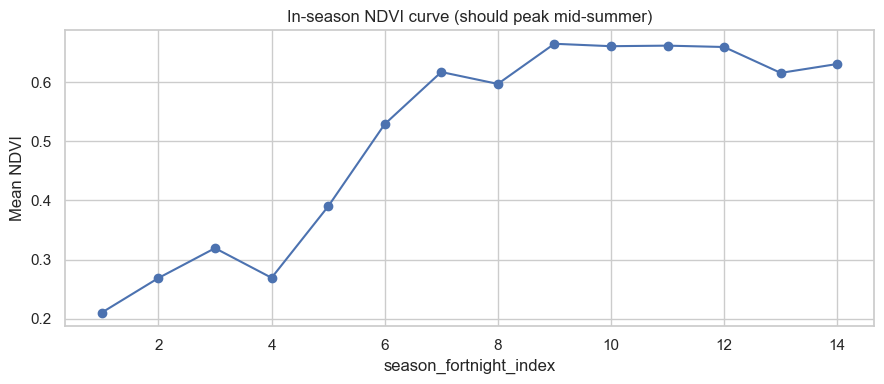

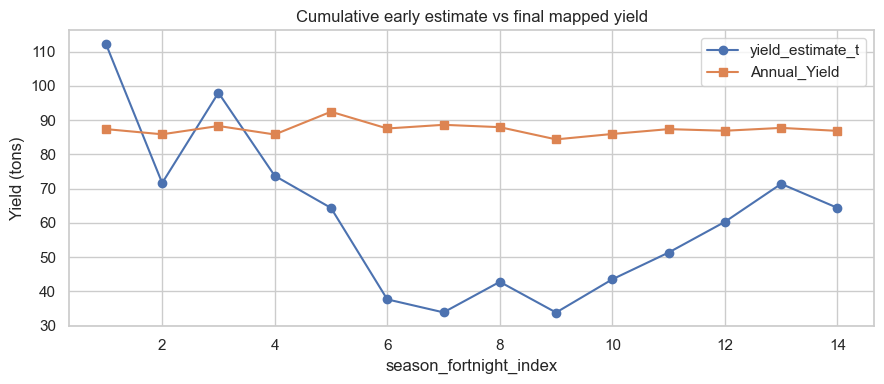

In [20]:
# NDVI should peak mid-summer (validates crop-season filter)
ndvi_by_idx = mapped_df.groupby('season_fortnight_index')['NDVI'].mean()
plt.figure(figsize=(9, 4))
plt.plot(ndvi_by_idx.index, ndvi_by_idx.values, marker='o')
plt.xlabel('season_fortnight_index')
plt.ylabel('Mean NDVI')
plt.title('In-season NDVI curve (should peak mid-summer)')
plt.tight_layout()
plt.show()

# Early estimate convergence toward final Annual_Yield
by_idx = mapped_df.groupby('season_fortnight_index').agg(
    mean_estimate=('yield_estimate_t', 'mean'),
    mean_actual=('Annual_Yield', 'mean'),
)
plt.figure(figsize=(9, 4))
plt.plot(by_idx.index, by_idx['mean_estimate'], label='yield_estimate_t', marker='o')
plt.plot(by_idx.index, by_idx['mean_actual'], label='Annual_Yield', marker='s')
plt.xlabel('season_fortnight_index')
plt.ylabel('Yield (tons)')
plt.title('Cumulative early estimate vs final mapped yield')
plt.legend()
plt.tight_layout()
plt.show()

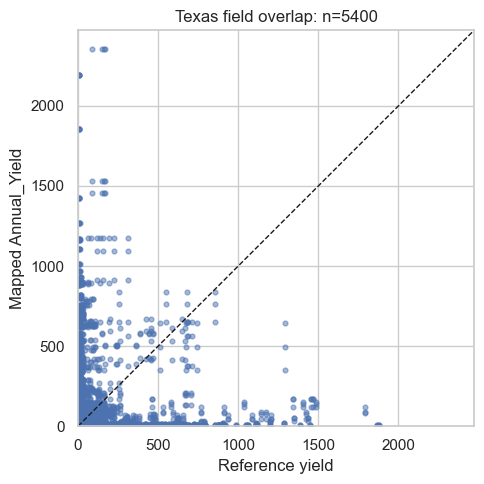

In [21]:
#compare mapped Texas yields vs reference field data (2018 only in reference CSV)
ref_path = next((p for p in TEXAS_REFERENCE_PATHS if os.path.exists(p)), None)
if ref_path:
    ref = pd.read_csv(ref_path)[['field_id', 'Yield']].rename(columns={'Yield': 'reference_yield'})
    tx = annual_df[annual_df['state'] == 'Texas'].merge(ref, on='field_id', how='inner')
    if len(tx):
        plt.figure(figsize=(5, 5))
        plt.scatter(tx['reference_yield'], tx['Annual_Yield'], alpha=0.5, s=12)
        lim = [0, max(tx['reference_yield'].max(), tx['Annual_Yield'].max()) * 1.05]
        plt.plot(lim, lim, 'k--', lw=1)
        plt.xlim(lim); plt.ylim(lim)
        plt.xlabel('Reference yield')
        plt.ylabel('Mapped Annual_Yield')
        plt.title(f'Texas field overlap: n={len(tx)}')
        plt.tight_layout()
        plt.show()
    else:
        print('No overlapping field_id with Texas reference CSV')
else:
    print('Texas reference CSV not found — skip comparison')